In [1]:
import geopandas as gpd
from pathlib import Path

Leído: RH28Ba_subc.shp — 1 features
Leído: RH28Bb_subc.shp — 1 features
Leído: RH28Bc_subc.shp — 1 features
Leído: RH28Bd_subc.shp — 1 features
Leído: RH28Be_subc.shp — 1 features
Leído: RH28Bf_subc.shp — 1 features
Leído: RH28Bg_subc.shp — 1 features
Leído: RH28Bh_subc.shp — 1 features
Leído: RH28Bi_subc.shp — 1 features
Leído: RH28Bj_subc.shp — 1 features
Leído: RH28Aa_subc.shp — 1 features
Leído: RH28Ab_subc.shp — 1 features
Leído: RH28Ac_subc.shp — 1 features
Leído: RH28Ad_subc.shp — 1 features
Leído: RH28Ae_subc.shp — 1 features
Leído: RH28Af_subc.shp — 1 features
Leído: RH28Ag_subc.shp — 1 features
Leído: RH28Ah_subc.shp — 1 features
Leído: RH28Ai_subc.shp — 1 features
Leído: RH28Aj_subc.shp — 1 features
Leído: RH28Ak_subc.shp — 1 features
Leído: RH28Al_subc.shp — 1 features
Leído: RH28Am_subc.shp — 1 features
Leído: RH28An_subc.shp — 1 features
Leído: RH28Ao_subc.shp — 1 features
Leído: RH28Ap_subc.shp — 1 features
Leído: RH28Aq_subc.shp — 1 features
Leído: RH28Ar_subc.shp — 1 f

<Axes: >

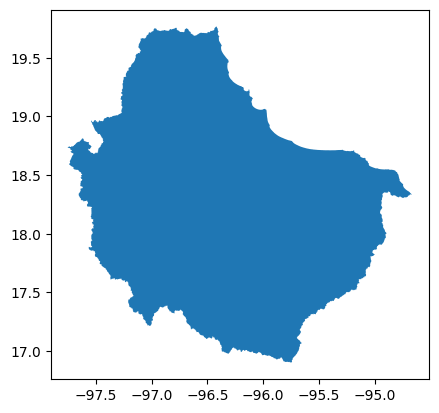

In [7]:

base = Path("../../data/raw/siatl")

partes = []
for shp in base.rglob("*_subc.shp"):
    gdf = gpd.read_file(shp)
    partes.append(gdf)
    print(f"Leído: {shp.name} — {len(gdf)} features")

rh28 = gpd.pd.concat(partes, ignore_index=True)
print(f"\nTotal subcuencas: {len(rh28)}")
print(f"Columnas: {rh28.columns.tolist()}")
print(f"CRS: {rh28.crs}")

papaloapan = rh28.dissolve()
papaloapan.plot()

CRS final: EPSG:4326
Área total aprox: 57,538 km²


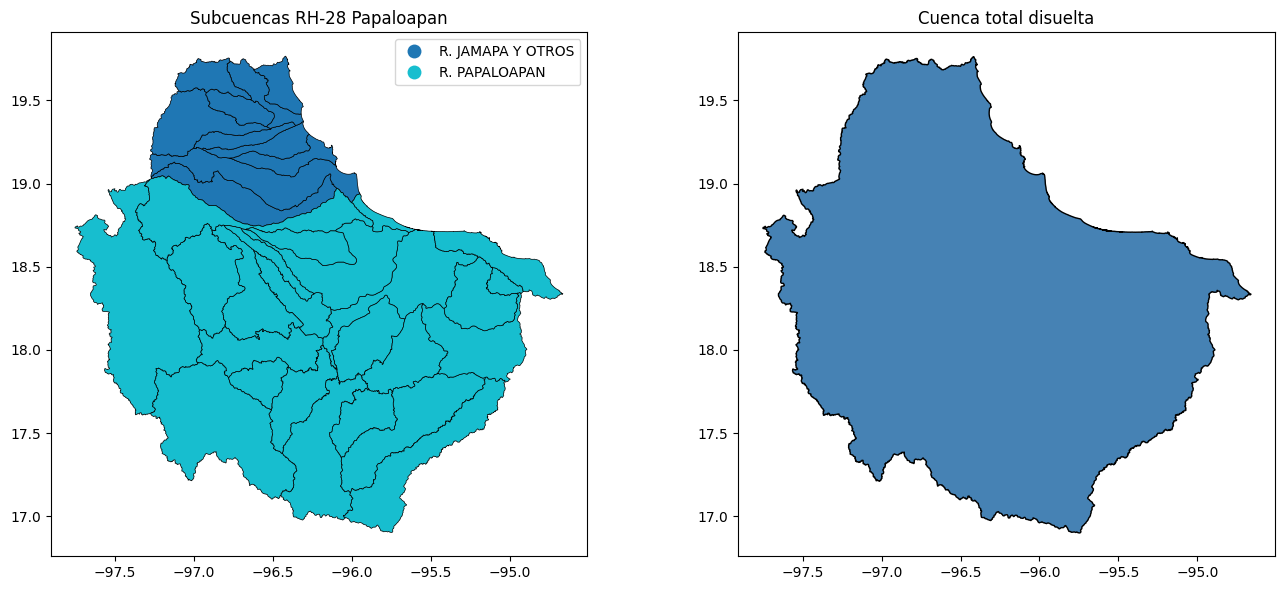

Figura guardada.


In [8]:
 import matplotlib.pyplot as plt

# Reproyectar a WGS84
rh28 = rh28.to_crs("EPSG:4326")

# Dissolve — polígono único de toda la cuenca
papaloapan = rh28.dissolve()

print(f"CRS final: {papaloapan.crs}")
print(f"Área total aprox: {rh28['AREA_KM2'].sum():,.0f} km²")

# Ver las subcuencas y el polígono total
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rh28.plot(ax=axes[0], column='CUENCA', legend=True, edgecolor='black', linewidth=0.5)
axes[0].set_title("Subcuencas RH-28 Papaloapan")

papaloapan.plot(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Cuenca total disuelta")

plt.tight_layout()
plt.savefig("../../outputs/figures/01_cuenca_papaloapan.png", dpi=150)
plt.show()

print("Figura guardada.")